<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week_09/prepare_cats_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the Dogs vs. Cats Dataset


The Dogs vs. Cats dataset is a collection of images for binary image classification. It contains a training set of labeled images of cats and dogs, originally used in a Kaggle competition (2013). Each image is a color photo. The dataset provides a challenging problem of distinguishing between two visually similar categories and is widely used for experimenting with convolutional neural networks.

The original dataset is available at:
- https://www.kaggle.com/c/dogs-vs-cats

We will work with a smaller dataset available at:
- http://zuzka.petricek.net/vyuka_2024/NES2_2024/data/cats_vs_dogs_small.zip

1. Download the zip file with the data
2. Extract the zip file

In [1]:
import requests
import zipfile
import os

zip_path = "cats_vs_dogs_small.zip"
url = "http://zuzka.petricek.net/vyuka_2024/NES2_2024/data/cats_vs_dogs_small.zip"
output_folder = "."

#base_folder ="cats_vs_dogs_small/"

# Download the zip file
response = requests.get(url)

# Save the zip file locally
with open(zip_path, "wb") as file:
    file.write(response.content)

# Extract the zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(output_folder)

# Clean up by removing the downloaded zip file
os.remove(zip_path)



## Process the data

### The format (structure) of the folder with data:
- in our case, the root folder contains three subdirectories: `train` (2000 images), `validation` (1000 images), and `test` (2000 images):

```
cats_vs_dogs_small/
├── train/
│   ├── Cat/
│   └── Dog/
├── validation/
│   ├── Cat/
│   └── Dog/
└── test/
│   ├── Cat/
│   └── Dog/
```

Observe the number of images in each folder:
- the dataset is balanced

In [2]:
import os

base_dir = "cats_vs_dogs_small"

for split in ["train", "validation", "test"]:
    split_dir = os.path.join(base_dir, split)
    print(f"\n{split.upper()}:")
    for category in ["Cat", "Dog"]:
        category_dir = os.path.join(split_dir, category)
        num_images = len(os.listdir(category_dir))
        print(f"  {category}: {num_images} images")


TRAIN:
  Cat: 1000 images
  Dog: 1000 images

VALIDATION:
  Cat: 500 images
  Dog: 500 images

TEST:
  Cat: 1000 images
  Dog: 1000 images


Observe some images:

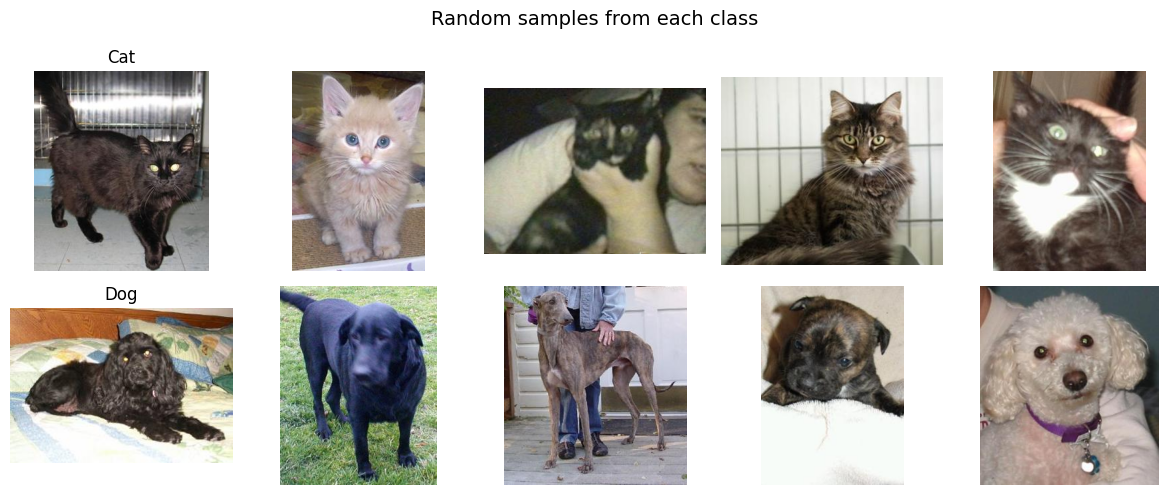

In [3]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_dir = "cats_vs_dogs_small/train"
classes = ["Cat", "Dog"]

fig, axes = plt.subplots(len(classes), 5, figsize=(12, 5))
fig.suptitle("Random samples from each class", fontsize=14)

for i, cls in enumerate(classes):
    class_dir = os.path.join(base_dir, cls)
    images = random.sample(os.listdir(class_dir), 5)

    for j, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(cls)

plt.tight_layout()
plt.show()